# 04 - Supervised Detection (Phase 4b)

## Setup

Same connection pattern as `01_eda.ipynb`, `02_methods.ipynb` and
`03_reconciliation.ipynb` - credentials from `.env`, jupysql for SQL cells,
pandas/sklearn pulled in only where a chart or a model needs them.

Unlike those three, **this notebook does query `ground_truth`** - it has to,
this is the supervised phase. The Hard rule it still has to respect: labels
only, joined at training/evaluation time, by `header_id`. The feature table
(`journal_entry_features`, Phase 2) itself was built with no `ground_truth`
join and stays that way - this notebook reads it as-is and attaches labels
on the pandas/SQL side, never writes back to it. `reversal_flag` isn't even
a column in the feature table, so there's no accidental-feature risk there
either.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

%load_ext sql

In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

user = quote_plus(os.environ["PGUSER"])
password = quote_plus(os.environ["PGPASSWORD"])
conn_str = (
    f"postgresql+psycopg2://{user}:{password}"
    f"@{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}"
)
engine = create_engine(conn_str)

%sql engine
%config SqlMagic.displaylimit = 20
%config SqlMagic.feedback = False
%config SqlMagic.autopandas = False

## 1. Labels - joining `ground_truth` by `header_id`

`journal_entry_features` is one row per `journal_header`. `ground_truth`
is one row per *finding*, and can point at a `header_id`, a `line_id`, or a
`bank_txn_id` (never more than one is guaranteed, see `sql/01_schema.sql`).
Two things fall out of that:

- **Bank-side `unmatched_bank` rows have `header_id IS NULL`** (a phantom
  bank row has no ledger header to point at at all) - filtering
  `WHERE header_id IS NOT NULL` drops exactly those, which is correct here:
  they can't join to a header-level feature table because there's no header
  to join to. They stay entirely out of scope for this notebook (they were
  in scope for the reconciliation blocking/scoring work in
  `03_reconciliation.ipynb` / Phase 5, not here).
- **A header can carry more than one `ground_truth` row.** Checked directly
  against the live DB: 18 headers have exactly 2 (out of ~5,000 flagged
  headers) - almost all of the seeded error pools are drawn disjointly from
  each other, but `unmatched_bank`'s ledger-side pool is drawn from
  cash-touching lines independently of the other error types' shared
  eligible-header pool, so a rare overlap is possible. `array_agg(DISTINCT
  ...)` keeps both labels visible on that header instead of one silently
  overwriting the other.

The label itself is a simple existence flag: `is_error = TRUE` iff the
header appears anywhere in `ground_truth`.

In [3]:
%%sql labelled_rs <<
SELECT
    f.*,
    (g.header_id IS NOT NULL)                      AS is_error,
    COALESCE(g.error_types, ARRAY[]::text[])       AS error_types,
    COALESCE(g.detectabilities, ARRAY[]::text[])   AS detectabilities
FROM journal_entry_features f
LEFT JOIN (
    -- one row per flagged header, arrays absorb the rare double-label case
    SELECT
        header_id,
        array_agg(DISTINCT error_type)   AS error_types,
        array_agg(DISTINCT detectability) AS detectabilities
    FROM ground_truth
    WHERE header_id IS NOT NULL   -- excludes phantom bank-only rows, see above
    GROUP BY header_id
) g ON g.header_id = f.header_id;

In [4]:
df = labelled_rs.DataFrame()
print(df.shape)
print(df.groupby("split")["is_error"].agg(["mean", "sum", "count"]))

(113981, 32)
           mean   sum  count
split                       
test   0.045060  1293  28695
train  0.044181  3768  85286


Positive rate is close to CLAUDE.md's ~3% target and, more importantly
for a time-based split, close to *each other* between train and test
(~4.4% vs ~4.5%) - the error mix isn't drifting sharply across the 18/6
period boundary, so a model trained on the train-period rate shouldn't be
walking into a very different base rate at test time.

## 2. Class imbalance - how it's handled

~4-5% positive is imbalanced enough that a model optimizing raw accuracy
could hit >95% by predicting "clean" every time and be useless. Three
options exist: resample (SMOTE/undersampling), reweight the loss
(`class_weight` / `scale_pos_weight`), or do nothing and rely on the metric
(PR curve) to tell the story. This notebook reweights, and explicitly does
**not** resample:

- **No synthetic minority oversampling (SMOTE).** `error_type` in this
  dataset is not one homogeneous "fraud" signature - `round_number`,
  `structuring`, `backdated`, `unusual_account_pair`, etc. each have a
  different feature footprint (see `sql/02_features.sql`'s comments on
  `is_manual_entry`, `is_last_two_days`, `account_amount_zscore`...).
  SMOTE interpolates between two positive examples in feature space; a
  synthetic point drawn between a `structuring` header and a `backdated`
  header describes an error type that was never actually seeded - it's a
  chart of a hallucinated pattern, not a real one. That's a bad trade for a
  20-25 minute defend-every-choice interview answer.
- **No random undersampling of the majority class.** Throwing away clean
  rows shrinks an already-modest 113,981-row dataset further and would
  bias the `account_amount_zscore` / frequency features (which are running
  counts over *all* prior rows) toward a distribution the deployed model
  would never see in production, where every clean row still occurs.
- **`class_weight="balanced"`** (logistic regression, random forest) and
  **`scale_pos_weight`** (XGBoost) instead: both just reweight the existing
  rows in the loss function, computed from the **train split only** so no
  test-period information leaks into the weighting. Nothing is fabricated,
  nothing is thrown away, and the reweighting is a single reproducible
  number I can quote and defend directly.
- **Accuracy is not reported below.** With a ~95/5 split, accuracy is close
  to meaningless on its own - precision/recall/F1 and the PR curve (Section
  7) are the metrics that actually describe operating behaviour at this
  imbalance, same reasoning CLAUDE.md gives for why a single flat recall
  number across all detectability tiers would be meaningless (Section 8
  breaks that out too).

## 3. Preprocessing

Feature columns are every column in `journal_entry_features` except
identifiers (`header_id`, `header_id_text`) and time-index metadata
(`fiscal_period`, `split` - used to cut train/test, not fed to the model).
`is_error` / `error_types` / `detectabilities` are the label, not features -
kept out of `X` explicitly below rather than trusted to a "drop everything
that isn't numeric" shortcut, so it's obvious at a glance nothing from
`ground_truth` reaches the model input.

Three groups get different treatment:

- **Numeric** (amounts, running counts, lags): median-imputed with a
  `add_indicator` flag, then standardized. The only column that actually
  has nulls here is `account_amount_zscore` (NULL when an account has
  <=10 prior entries - see `sql/02_features.sql`'s comment on
  `account_entry_seq > 10`) - that's *informative* missingness (thin
  history), not random, so `add_indicator=True` keeps "we didn't have
  enough history to compute this" visible to the model as its own signal
  rather than silently smoothing it into the imputed value.
- **Boolean flags** (`is_round_100`, `is_after_hours`, ...): passed through
  as 0/1. No missing values, no scaling needed - a 0/1 indicator's own
  scale is already meaningful to both a linear model's coefficient and a
  tree's split threshold.
- **`debit_account_key` / `credit_account_key`**: one-hot encoded. Only 27
  accounts (`N_ACCOUNTS` in `data/generate_journal_entries.py`), so the
  encoded width stays small (54 columns), and these are nominal account
  identifiers, not an ordinal quantity - feeding the raw integer key to a
  linear model would imply an arithmetic relationship between account 12
  and account 13 that doesn't exist.

One `ColumnTransformer` is reused, unchanged, across all three models
below. Random forest and XGBoost don't need the scaling or the one-hot
encoding (they'd split just as well on a raw integer account key or an
unscaled amount) - but reusing the same preprocessing means all three
models see literally the same design matrix, so any difference in their
scores is coming from the model, not from three different feature
pipelines quietly disagreeing with each other.

In [5]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

TARGET = "is_error"

numeric_features = [
    "total_amount", "log_amount", "leading_digit",
    "account_entry_seq", "account_amount_zscore", "pct_of_account_monthly_total",
    "days_from_period_end", "post_lag_days",
    "employee_entry_seq", "user_account_frequency", "user_entry_count_month",
    "entry_line_count", "description_length",
    "account_pair_frequency",
]
boolean_features = [
    "is_round_100", "is_round_1000", "is_round_10000",
    "is_last_two_days", "is_after_hours", "is_weekend",
    "has_description", "is_first_time_pair", "is_manual_entry",
]
categorical_features = ["debit_account_key", "credit_account_key"]

feature_cols = numeric_features + boolean_features + categorical_features

X = df[feature_cols].copy()
for c in boolean_features:
    X[c] = X[c].astype(int)
for c in categorical_features:
    X[c] = X[c].astype(str)   # nominal id, not a quantity - see markdown above

y = df[TARGET].astype(int)
split = df["split"]

X_train, X_test = X[split == "train"], X[split == "test"]
y_train, y_test = y[split == "train"], y[split == "test"]
# header_id + label detail for the test rows only, carried alongside for the
# error-type / detectability breakdown in Section 8 - never fed to a model
meta_test = df.loc[split == "test", ["header_id", "error_types", "detectabilities"]]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("bool", "passthrough", boolean_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

print(f"train: {X_train.shape}, test: {X_test.shape}, positive rate train={y_train.mean():.4f} test={y_test.mean():.4f}")

train: (85286, 25), test: (28695, 25), positive rate train=0.0442 test=0.0451


## 4. Model 1 - Logistic regression (baseline)

Linear baseline first, deliberately - it sets the bar the tree models
need to clear to justify their extra complexity. `class_weight="balanced"`
reweights the loss inversely to class frequency in `y_train` (computed by
sklearn internally from the training fold only).

In [6]:
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]

## 5. Model 2 - Random forest

Trees can pick up interactions and non-linear thresholds a linear model
can't - e.g. `structuring`'s signal is amounts sitting *just under* the
$10,000 threshold (`data/generate_journal_entries.py::THRESHOLD`), which is
a non-monotonic relationship with `total_amount` a linear coefficient can't
represent, but a tree split at ~$9,700 can. Same `class_weight="balanced"`
reasoning as the logistic regression.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=3,   # small guard against single-row leaves on a 4-5% positive class
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])
rf_pipe.fit(X_train, y_train)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

## 6. Model 3 - XGBoost

Gradient boosting, same feature set. Imbalance is handled the XGBoost-native
way - `scale_pos_weight`, the ratio of negative to positive examples,
computed from `y_train` only (never `y_test` - even a single scalar
hyperparameter derived from the test split would be a small leak of test-set
information into the fitted model).

In [8]:
from xgboost import XGBClassifier

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
scale_pos_weight = n_neg / n_pos
print(f"train: {n_neg} clean / {n_pos} error -> scale_pos_weight = {scale_pos_weight:.2f}")

xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1,
    )),
])
xgb_pipe.fit(X_train, y_train)
xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]

models = {
    "Logistic Regression": lr_proba,
    "Random Forest": rf_proba,
    "XGBoost": xgb_proba,
}
# fixed categorical order, never cycled/reassigned - slots 1/2/3 of the
# validated default palette, chosen because they clear the CVD-safety
# checks pairwise (not just adjacent) for exactly a 3-series chart
MODEL_COLORS = {
    "Logistic Regression": "#2a78d6",  # slot 1 - blue
    "Random Forest": "#eb6834",        # slot 2 - orange
    "XGBoost": "#1baf7a",              # slot 3 - aqua
}

train: 81518 clean / 3768 error -> scale_pos_weight = 21.63


## 7. Evaluation - precision, recall, F1, PR curves

Why PR curves and not ROC: with positives at ~4.5% of test, ROC-AUC stays
high even for a mediocre model, because the false-positive *rate* denominator
is dominated by the huge negative class - it under-states how many of the
"error" flags a reviewer would actually have to chase down are false alarms.
Precision-recall doesn't have that denominator problem, so it's the honest
view at this imbalance - the same reasoning CLAUDE.md gives for why a single
flat recall number is meaningless applies to a single flat AUC number too.

`classification_report` below is at the default 0.5 probability threshold -
meaningful here specifically because `class_weight`/`scale_pos_weight`
already rebalanced the loss, so 0.5 corresponds to the reweighted decision
boundary rather than an arbitrary cut on a raw 95/5-skewed score.

In [9]:
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score

for name, proba in models.items():
    print(f"--- {name} (threshold 0.5) ---")
    print(classification_report(y_test, (proba >= 0.5).astype(int), digits=3, target_names=["clean", "error"]))

--- Logistic Regression (threshold 0.5) ---
              precision    recall  f1-score   support

       clean      0.983     0.842     0.907     27402
       error      0.172     0.696     0.276      1293

    accuracy                          0.836     28695
   macro avg      0.578     0.769     0.592     28695
weighted avg      0.947     0.836     0.879     28695

--- Random Forest (threshold 0.5) ---
              precision    recall  f1-score   support

       clean      0.979     0.991     0.985     27402
       error      0.739     0.555     0.634      1293

    accuracy                          0.971     28695
   macro avg      0.859     0.773     0.809     28695
weighted avg      0.968     0.971     0.969     28695

--- XGBoost (threshold 0.5) ---
              precision    recall  f1-score   support

       clean      0.982     0.964     0.973     27402
       error      0.448     0.626     0.523      1293

    accuracy                          0.948     28695
   macro avg  

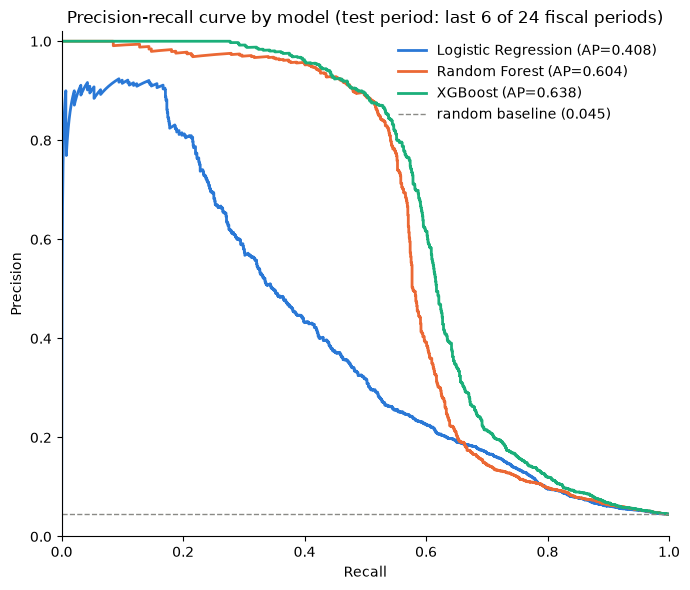

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in models.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, lw=2, color=MODEL_COLORS[name], label=f"{name} (AP={ap:.3f})")

baseline_rate = y_test.mean()
ax.axhline(baseline_rate, color="#8a8a86", lw=1, linestyle="--",
           label=f"random baseline ({baseline_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curve by model (test period: last 6 of 24 fiscal periods)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary_df = pd.DataFrame([
    {
        "model": name,
        "precision": precision_score(y_test, (proba >= 0.5).astype(int)),
        "recall": recall_score(y_test, (proba >= 0.5).astype(int)),
        "f1": f1_score(y_test, (proba >= 0.5).astype(int)),
        "average_precision": average_precision_score(y_test, proba),
    }
    for name, proba in models.items()
]).set_index("model").round(3)
summary_df

,precision,recall,f1,average_precision
model,,,,
Logistic Regression,0.172,0.696,0.276,0.408
Random Forest,0.739,0.555,0.634,0.604
XGBoost,0.448,0.626,0.523,0.638


## 8. Recall by error type and detectability tier

A single flat recall number blends 1,033 `hard`-tier `structuring` headers
with 338 `easy`-tier `unbalanced` headers into one average - exactly the
"meaningless if everything is equally easy or the number hides the mix"
problem CLAUDE.md's Hard rules call out. Breaking recall out by
`error_type` and by `detectability` is the honest version of this metric.

One thing to watch for specifically: `backdated`'s `hard` tier was
deliberately calibrated (Phase 1b, see CLAUDE.md's Data shape targets) so
that ~17.5% of it (`UNDETECTABLE_FRAC`) carries *none* of the three risk
drivers (manual source, after-hours, period-end) the generator otherwise
weights backdating toward - that slice is undetectable by design, not a
modelling shortfall. `hard`-tier recall below has an honest ceiling well
under 100% for exactly that reason, and that's expected, not a bug to chase.

In [12]:
pred_df = meta_test.copy()
for name, proba in models.items():
    pred_df[name] = (pd.Series(proba, index=meta_test.index) >= 0.5).astype(int)
pred_df["is_error"] = y_test.values

# explode the parallel error_types/detectabilities arrays - one row per
# (header, error_type) pair, so a doubly-labelled header (Section 1) counts
# toward the recall of both error types it actually carries
rows = []
for header_id, r in pred_df[pred_df["is_error"] == 1].iterrows():
    for error_type, detectability in zip(r["error_types"], r["detectabilities"]):
        rows.append({
            "header_id": r["header_id"], "error_type": error_type, "detectability": detectability,
            **{name: r[name] for name in models},
        })
exploded = pd.DataFrame(rows)
print(f"{len(exploded)} labelled (header, error_type) pairs in the test period")

1297 labelled (header, error_type) pairs in the test period


In [13]:
recall_by_type = exploded.groupby("error_type")[list(models)].mean().round(3)
recall_by_type["n"] = exploded.groupby("error_type").size()
recall_by_type.sort_values("n", ascending=False)

,Logistic Regression,Random Forest,XGBoost,n
error_type,,,,
round_number,1.000,1.000,1.000,274
structuring,0.864,0.682,0.868,242
backdated,0.442,0.138,0.298,181
off_hours_posting,0.968,0.721,0.799,154
unusual_account_pair,0.833,0.887,0.893,150
duplicate,0.203,0.022,0.043,138
unmatched_bank,0.171,0.037,0.049,82
unbalanced,0.316,0.066,0.105,76


**Finding worth flagging**: recall on `unbalanced`, `duplicate`, and
`unmatched_bank` is near zero for random forest and XGBoost (0.02-0.11),
while logistic regression catches noticeably more of each (0.17-0.32) at
the cost of a lot of false positives elsewhere. This isn't a tuning problem
- `journal_entry_features` (Phase 2) simply carries no feature that
represents any of the three directly:

- `unbalanced` needs the actual `SUM(debit_amount) - SUM(credit_amount)`
  imbalance magnitude - not in the feature table.
- `duplicate` needs a same-account/same-amount/same-employee proximity
  count within a short window - not in the feature table.
- `unmatched_bank` needs bank-reconciliation status, which is exactly the
  fuzzy-matching problem `03_reconciliation.ipynb` exists to solve
  separately, on purpose (see that notebook's Section 1) - it was never
  meant to be inferable from `journal_entry_features` alone.

The trees learn the round-number / structuring / off-hours / account-pair
signals well (all of those *do* have direct features - `is_round_*`,
`total_amount` vs. the $10k threshold, `is_after_hours`, `is_first_time_pair`
/ `account_pair_frequency`) and effectively ignore the three types they have
no signal for, since chasing weak indirect correlations on those doesn't pay
off against a `class_weight`-reweighted loss with plenty of learnable signal
elsewhere. The logistic regression's much higher recall on the same three
types isn't it "understanding" them better - it's a high-variance linear
model with `class_weight="balanced"` firing more false positives across the
board (0.172 overall precision vs. 0.739 RF / 0.448 XGB, Section 7), so it
incidentally nets a few of the unbalanced/duplicate/unmatched_bank headers
too, not because it has a stronger read on those types specifically. Not a
bug to fix here - it's a real limitation of this feature table for those
three error types, worth carrying into Phase 5's scoreboard and into
`sql/02_features.sql` as a note for a future iteration if closing this gap
ever becomes a priority.

In [14]:
# unbalanced/duplicate/unmatched_bank have no direct feature (see the
# finding above) - split recall into "addressable" (the feature table
# actually carries signal for these) vs the rest, same (header, error_type)
# pair-level accounting as recall_by_type above, for consistency
UNADDRESSABLE_TYPES = ["unbalanced", "duplicate", "unmatched_bank"]
ADDRESSABLE_TYPES = [t for t in exploded["error_type"].unique() if t not in UNADDRESSABLE_TYPES]

addressable_mask = exploded["error_type"].isin(ADDRESSABLE_TYPES)

recall_split = pd.DataFrame({
    "overall_recall (header-level, Section 7)": {name: recall_score(y_test, (proba >= 0.5).astype(int)) for name, proba in models.items()},
    "addressable_recall (pair-level)": exploded.loc[addressable_mask, list(models)].mean(),
    "unaddressable_recall (pair-level)": exploded.loc[~addressable_mask, list(models)].mean(),
}).round(3)
recall_split["n_addressable"] = int(addressable_mask.sum())
recall_split["n_unaddressable"] = int((~addressable_mask).sum())
recall_split

,"overall_recall (header-level, Section 7)",addressable_recall (pair-level),unaddressable_recall (pair-level),n_addressable,n_unaddressable
Logistic Regression,0.696,0.836,0.223,1001,296
Random Forest,0.555,0.707,0.037,1001,296
XGBoost,0.626,0.794,0.061,1001,296


**Overall recall vs. addressable-subset recall.** "Overall recall" (Section
7, header-level, matches `summary_df`) blends every error type into one
number - including the three types the feature table has no direct signal
for at all. Restricting to the five types it *can* address
(`round_number`, `backdated`, `off_hours_posting`, `unusual_account_pair`,
`structuring`) removes that drag and shows what each model can actually do
on the classes it has something to work with; the `unaddressable_recall`
column is the mirror of that, confined to `unbalanced`/`duplicate`/
`unmatched_bank`.

Two accounting levels are mixed here on purpose, and it's worth being
explicit about why: `overall_recall` is header-level (one row per header,
exactly `summary_df`'s number), while the addressable/unaddressable split
is pair-level (one row per (header, error_type), same as `recall_by_type`
above) - the 18 doubly-labelled headers (Section 1) mean these two
accountings aren't perfectly identical to the last decimal, but the gap
between addressable and unaddressable recall is large enough (0.71-0.84
vs. 0.04-0.22 per model, per the table above) that this rounding-level
difference doesn't change the conclusion.

The gap between `addressable_recall` and `unaddressable_recall` is a
**feature-coverage limitation, not a model limitation** - all three models
were handed the same columns, and none of those columns encodes a balance
defect, a duplicate-proximity count, or reconciliation status. No amount of
hyperparameter tuning on random forest or XGBoost closes that gap; only
adding the missing features to `journal_entry_features` would.

In [15]:
tier_order = ["easy", "medium", "hard"]
recall_by_tier = (
    exploded.groupby("detectability")[list(models)].mean()
    .reindex(tier_order)
    .round(3)
)
recall_by_tier["n"] = exploded.groupby("detectability").size().reindex(tier_order)
recall_by_tier

,Logistic Regression,Random Forest,XGBoost,n
detectability,,,,
easy,0.771,0.683,0.702,420
medium,0.600,0.397,0.488,330
hard,0.697,0.550,0.653,547


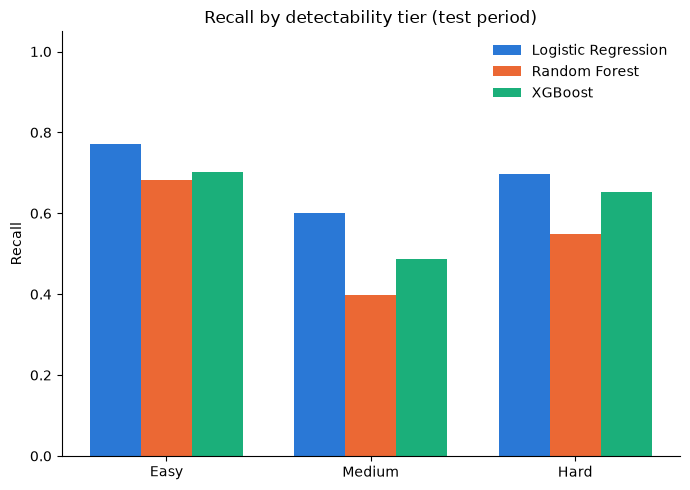

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(tier_order))
width = 0.25
for i, name in enumerate(models):
    ax.bar(x + (i - 1) * width, recall_by_tier[name], width, color=MODEL_COLORS[name], label=name)

ax.set_xticks(x)
ax.set_xticklabels([t.capitalize() for t in tier_order])
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
ax.set_title("Recall by detectability tier (test period)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 9. SHAP - global and individual explanations

Run on XGBoost - it's the model with the highest average precision above
(confirmed after running Sections 6-7), and `shap.TreeExplainer` gives
exact Shapley values for tree ensembles in polynomial time (unlike
`KernelExplainer`, which is model-agnostic but samples/approximates and is
far slower on ~29k test rows). `X_test` is transformed through the same
fitted `preprocessor` used at training time, so the SHAP values line up
with the one-hot/imputed feature space the model actually saw.

In [17]:
import shap

X_test_transformed = xgb_pipe.named_steps["prep"].transform(X_test)
feature_names = xgb_pipe.named_steps["prep"].get_feature_names_out()

explainer = shap.TreeExplainer(xgb_pipe.named_steps["clf"])
shap_values = explainer.shap_values(X_test_transformed)   # exact, one row per test example
print(shap_values.shape)

(28695, 78)


**Global**: a beeswarm summary plot over a random sample of the test
set (sampled only for plot legibility - the underlying SHAP values above are
exact for every row, sampling doesn't touch that).

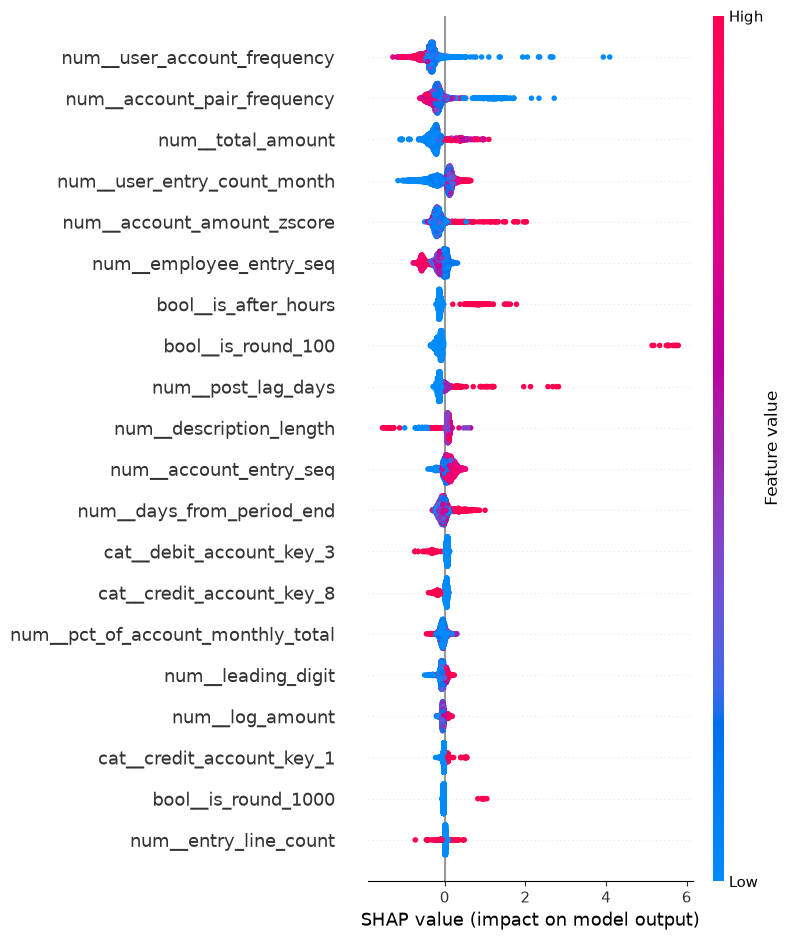

In [18]:
sample_idx = np.random.RandomState(42).choice(X_test_transformed.shape[0], size=2000, replace=False)
shap.summary_plot(
    shap_values[sample_idx], X_test_transformed[sample_idx],
    feature_names=feature_names, show=False,
)
plt.tight_layout()
plt.show()

In [19]:
# Group features by the same AMOUNT / TIMING / BEHAVIOURAL / STRUCTURAL
# sections sql/02_features.sql itself is organized under (see that file's
# section comments) - not a new taxonomy invented here, the project's own.
# One-hot dummies for debit/credit_account_key all fold back into
# "structural" (they're one input feature, account identity, encoded as
# many columns); the imputation-missing indicator folds into
# account_amount_zscore's group, same underlying feature.
FEATURE_GROUP = {
    "total_amount": "amount", "log_amount": "amount", "leading_digit": "amount",
    "is_round_100": "amount", "is_round_1000": "amount", "is_round_10000": "amount",
    "account_entry_seq": "amount", "account_amount_zscore": "amount",
    "pct_of_account_monthly_total": "amount",
    "days_from_period_end": "timing", "is_last_two_days": "timing",
    "is_after_hours": "timing", "is_weekend": "timing", "post_lag_days": "timing",
    "employee_entry_seq": "behavioural", "user_account_frequency": "behavioural",
    "user_entry_count_month": "behavioural", "entry_line_count": "behavioural",
    "has_description": "behavioural", "description_length": "behavioural",
    "debit_account_key": "structural", "credit_account_key": "structural",
    "account_pair_frequency": "structural", "is_first_time_pair": "structural",
    "is_manual_entry": "structural",
}

def original_feature(shap_col_name):
    # strip the ColumnTransformer prefix (num__/bool__/cat__) and, for a
    # one-hot dummy, its trailing _<account_key> level
    name = shap_col_name.split("__", 1)[1]
    if name == "missingindicator_account_amount_zscore":
        return "account_amount_zscore"
    if name.startswith("debit_account_key_"):
        return "debit_account_key"
    if name.startswith("credit_account_key_"):
        return "credit_account_key"
    return name

col_to_original = {n: original_feature(n) for n in feature_names}

# importance per ORIGINAL input feature: sum the SHAP values of every
# transformed column belonging to it, per row (correct for one-hot - only
# one dummy is "on" per row, but a tree can and does split on the others
# being off too, so they can carry nonzero SHAP as well), then mean(|.|)
# across rows - the standard way to roll a one-hot-encoded categorical's
# SHAP columns back into one importance number for the original feature
shap_df = pd.DataFrame(shap_values, columns=feature_names)
grouped = shap_df.T.groupby(col_to_original).sum().T   # sum -> one column per original feature
feature_importance = grouped.abs().mean().sort_values(ascending=False)

top15 = feature_importance.head(15).rename("mean_abs_shap").to_frame()
top15["group"] = top15.index.map(FEATURE_GROUP)
top15

,mean_abs_shap,group
user_account_frequency,0.388036,behavioural
account_pair_frequency,0.297384,structural
total_amount,0.284592,amount
user_entry_count_month,0.232370,behavioural
account_amount_zscore,0.197401,amount
employee_entry_seq,0.190143,behavioural
is_round_100,0.180730,amount
is_after_hours,0.180278,timing
credit_account_key,0.167425,structural
debit_account_key,0.136938,structural


In [20]:
top15["group"].value_counts().rename("count_in_top_15")

group
amount         5
behavioural    4
structural     3
timing         3
Name: count_in_top_15, dtype: int64

**Checking the EDA hypothesis.** Phase 3's EDA (`01_eda.ipynb`, findings
8/9/11) found posting volume heavily concentrated by employee and by
account (Zipf/power-law - one employee alone posted ~20% of all headers)
and role a much stronger amount split than account type - the read at the
time was that *behavioural* signal (who's posting, how often, in what
pattern) would end up outranking *structural* signal (which specific
accounts, how many lines) once a model actually got built. The top-15 SHAP
ranking above (re-run after the Section 11.2 generator fix - see that
section for why an earlier run of this exact cell looked different):

| rank | feature | group | mean &#124;SHAP&#124; |
|---|---|---|---|
| 1 | `user_account_frequency` | behavioural | 0.388 |
| 2 | `account_pair_frequency` | structural | 0.297 |
| 3 | `total_amount` | amount | 0.285 |
| 4 | `user_entry_count_month` | behavioural | 0.232 |
| 5 | `account_amount_zscore` | amount | 0.197 |
| 6 | `employee_entry_seq` | behavioural | 0.190 |
| 7 | `is_round_100` | amount | 0.181 |
| 8 | `is_after_hours` | timing | 0.180 |
| 9 | `credit_account_key` | structural | 0.167 |
| 10 | `debit_account_key` | structural | 0.137 |
| 11 | `post_lag_days` | timing | 0.136 |
| 12 | `description_length` | behavioural | 0.134 |
| 13 | `account_entry_seq` | amount | 0.129 |
| 14 | `days_from_period_end` | timing | 0.121 |
| 15 | `pct_of_account_monthly_total` | amount | 0.069 |

Group counts across the top 15: **amount 5, behavioural 4, structural 3,
timing 3** - the same tally as the pre-fix run, but the composition moved:
`description_length` dropped from #3 to #12 (Section 11.2 confirms why),
and `total_amount` took its place near the top, jumping from #9 to #3.

**Verdict: partially confirmed, and more modestly than the pre-fix ranking
suggested.** The single most important feature is still behavioural
(`user_account_frequency`), which is a genuine hit for the EDA's
prediction. But behavioural's apparent dominance at the top was partly the
leak talking: with `description_length` restored to its real, unremarkable
value, behavioural holds 3 of the top 6 slots (#1, #4, #6), not 4 - amount
is right there with it (#3, #5, #7) and structural's `account_pair_frequency`
sits at #2, one spot behind the leading behavioural feature. It's closer to
a three-way contest at the top than a behavioural sweep.

The underlying reason is the same as before, and holds up better post-fix
than pre-fix: none of the eight seeded error types is a *pure*
behavioural-frequency signature. `round_number`, `structuring`, and partly
`backdated` are fundamentally amount-shaped; `unusual_account_pair` is
fundamentally structural. Behavioural earns its #1 spot honestly this
time - `user_account_frequency` doesn't correspond to any single error
type's construction the way `is_round_100` maps to `round_number`, so its
lead reflects broad, cross-cutting usefulness (an unusual account for this
employee is weak evidence across several error types at once) rather than
one error type routing straight through it. That's a more interesting
result than the pre-fix ranking gave credit for: the strongest feature
isn't the one with the cleanest construction story, it's the one that
generalizes across labels - but it no longer runs away with the top of the
ranking the way it first appeared to.

**Bottom line: partially confirmed**, same verdict as before the fix, but
for a cleaner reason now - not "behavioural dominates the top, amount and
structural are secondary," but "all three (behavioural, amount, structural)
are competitive at the top, with behavioural's single strongest feature
narrowly leading because it isn't tied to one error type the way most of
the amount/structural features are."

**Individual**: two contrasting cases from the test set's actual
positives - an `easy`-tier header the model flags with high confidence, and
a `hard`-tier header it's least confident about. The waterfall plot shows
which features pushed each one's score up or down from the model's base
rate, row by row - the "defend this specific call" view a summary plot
can't give.

Easy tier - confident catch: header_id=5604, predicted_prob=0.999, error_types=['round_number'], detectability=['easy']


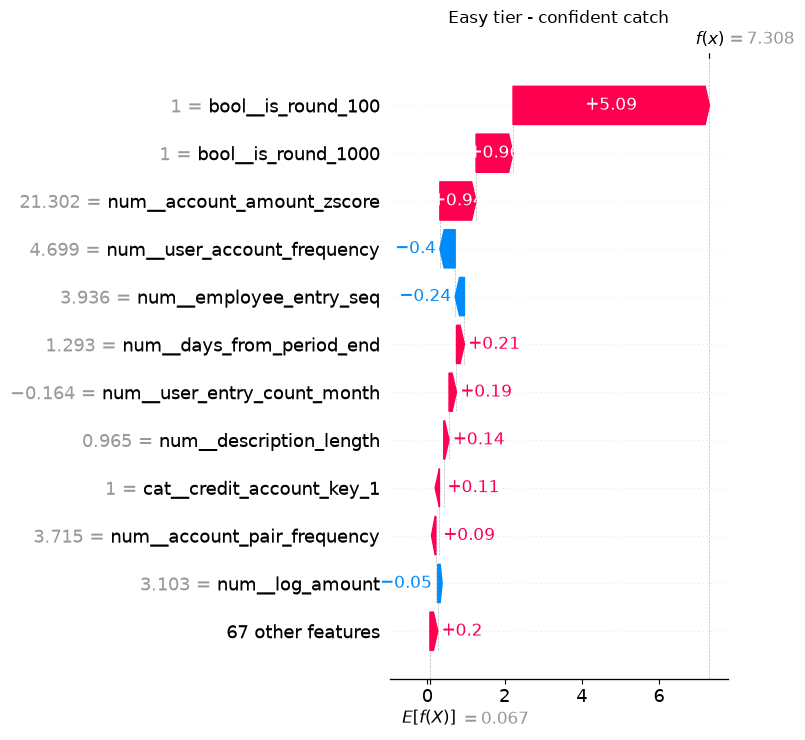

Hard tier - least-confident true positive: header_id=20524, predicted_prob=0.060, error_types=['backdated'], detectability=['hard']


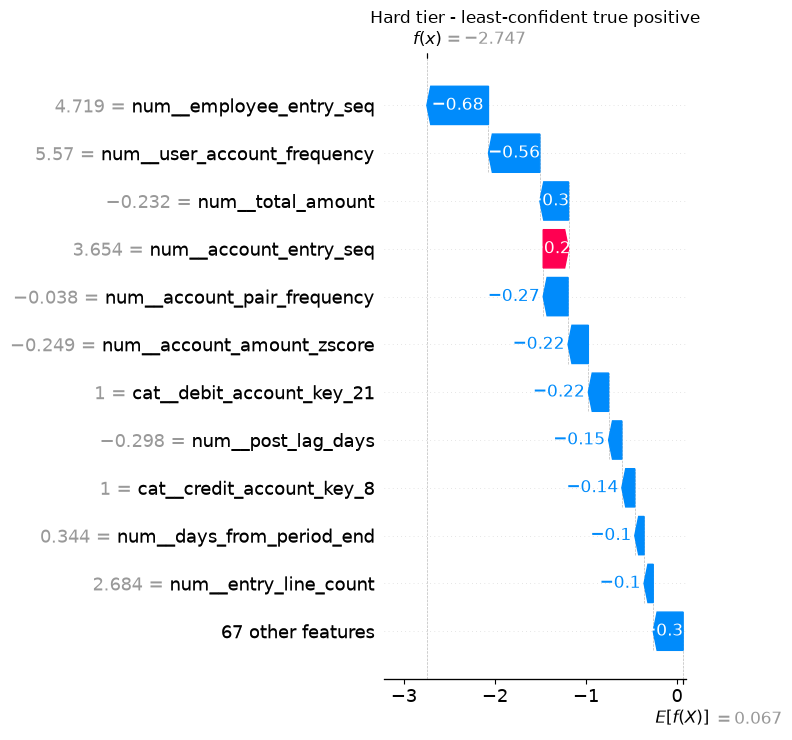

In [21]:
proba_series = pd.Series(xgb_proba, index=X_test.index)
is_easy = meta_test["detectabilities"].apply(lambda d: "easy" in d)
is_hard = meta_test["detectabilities"].apply(lambda d: "hard" in d)

easy_idx = proba_series[is_easy & (y_test == 1)].idxmax()   # confident catch
hard_idx = proba_series[is_hard & (y_test == 1)].idxmin()   # least-confident hard-tier true positive

for label, idx in [("Easy tier - confident catch", easy_idx),
                    ("Hard tier - least-confident true positive", hard_idx)]:
    pos = X_test.index.get_loc(idx)
    row = meta_test.loc[idx]
    print(f"{label}: header_id={row['header_id']}, predicted_prob={proba_series[idx]:.3f}, "
          f"error_types={row['error_types']}, detectability={row['detectabilities']}")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[pos],
            base_values=explainer.expected_value,
            data=X_test_transformed[pos],
            feature_names=feature_names,
        ),
        max_display=12, show=False,
    )
    plt.title(label)
    plt.tight_layout()
    plt.show()

## 10. Summary

Section 7's `summary_df` and PR curves, and Section 8's per-type/per-tier
recall tables, are the numbers Phase 5 (`notebooks/05_evaluation.ipynb`)
will carry forward. Per the Phase plan, Phase 5 scores Phase 4a (Benford,
segmented outliers, Isolation Forest, reconciliation) and Phase 4b
(this notebook) as **two separate scoreboards** against `ground_truth`, not
blended into one ranking - a blind unsupervised method and a model trained
directly on the labels aren't answering the same question, and conflating
them into a single leaderboard would hide that. `hard`-tier recall in
particular is not expected to reach 100% for either scoreboard - Section 8
above documents the deliberate ~17.5% undetectable slice within `backdated`
hard, and the generator's other `hard`-tier error types (`structuring`,
`unusual_account_pair`) were seeded to be genuinely difficult on purpose
(CLAUDE.md's "Seeded errors must vary in detectability" rule) - the
honest ceiling is part of the result, not a gap to close in Phase 5.

One result from this run worth carrying forward explicitly: random forest
posts the highest average precision (0.604) and XGBoost the highest recall
among the tree models (0.626, AP 0.638), both well ahead of the logistic
baseline (AP 0.408) - but all three collapse to near-zero recall on
`unbalanced`, `duplicate`, and `unmatched_bank` (Section 8), because the
feature table has no direct signal for any of those three. A single
"XGBoost wins" headline would hide that - which is the whole reason this
section breaks recall out by error type instead of reporting one number.

**This notebook was re-executed after the Section 11.2 fix** (generator no
longer leaks structuring's split marker into `entry_description`, data
regenerated, `journal_entry_features` rebuilt) - every number above is
post-fix. See Section 11 for the investigation that found and closed that
gap, kept as a record rather than scrubbed from the notebook.

## 11. Follow-up checks before closing 4b

Two things from Sections 8-9 needed verifying before trusting them (this
section documents the investigation as it happened - see the note in
Section 11.2 for the fix that came out of it and the re-run that followed):
`log_amount` not making the SHAP top 15 could be `account_amount_zscore`
absorbing its signal (both are amount-derived); and `description_length`
landing at #3 with no obvious construction link needed checking against
the generator directly rather than left as a guess.

### 11.1 Is `account_amount_zscore` absorbing `log_amount`?

Correlate the two first, then re-fit XGBoost with `account_amount_zscore`
dropped and see whether `log_amount`'s SHAP rank actually moves.

In [22]:
pearson_log_zscore = df[["log_amount", "account_amount_zscore"]].dropna().corr().iloc[0, 1]
spearman_log_zscore = df[["log_amount", "account_amount_zscore"]].dropna().corr(method="spearman").iloc[0, 1]
spearman_log_total = df["log_amount"].corr(df["total_amount"], method="spearman")
pearson_zscore_total = df[["account_amount_zscore", "total_amount"]].dropna().corr().iloc[0, 1]

print(f"log_amount vs account_amount_zscore   : pearson={pearson_log_zscore:.3f}  spearman={spearman_log_zscore:.3f}")
print(f"log_amount vs total_amount            : spearman={spearman_log_total:.3f}")
print(f"account_amount_zscore vs total_amount : pearson={pearson_zscore_total:.3f}")

log_amount vs account_amount_zscore   : pearson=0.485  spearman=0.773
log_amount vs total_amount            : spearman=1.000
account_amount_zscore vs total_amount : pearson=0.672


`log_amount` vs `account_amount_zscore` is a moderate 0.48 (Pearson) /
0.77 (Spearman) - correlated, but not so tightly that "zscore absorbed it"
is obvious from correlation alone. The more telling number:
`log_amount` vs `total_amount` has **Spearman correlation = 1.0 exactly**
- expected, since `log_amount = LN(total_amount + 1)` (`sql/02_features.sql`)
is a strictly monotonic transform of `total_amount`, and Spearman only
measures rank order. For a tree-based model that splits on thresholds, a
monotonic transform of a feature that's *already in the model* carries zero
additional ordering information - any split XGBoost could make on
`log_amount` has an exactly equivalent split on `total_amount`. That's the
more likely explanation, and it doesn't involve `account_amount_zscore` at
all. Re-fitting without `account_amount_zscore` is the direct test.

In [23]:
# same X_train/X_test rows, account_amount_zscore dropped from the numeric
# group - everything else (split, weights, model params) held identical to
# Section 6/9 so this is a clean one-variable ablation
numeric_features_ablated = [c for c in numeric_features if c != "account_amount_zscore"]

preprocessor_ablated = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), numeric_features_ablated),
    ("bool", "passthrough", boolean_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

xgb_pipe_ablated = Pipeline([
    ("prep", preprocessor_ablated),
    ("clf", XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        random_state=42, n_jobs=-1,
    )),
])
xgb_pipe_ablated.fit(X_train[numeric_features_ablated + boolean_features + categorical_features], y_train)

X_test_transformed_ablated = xgb_pipe_ablated.named_steps["prep"].transform(
    X_test[numeric_features_ablated + boolean_features + categorical_features]
)
feature_names_ablated = xgb_pipe_ablated.named_steps["prep"].get_feature_names_out()
explainer_ablated = shap.TreeExplainer(xgb_pipe_ablated.named_steps["clf"])
shap_values_ablated = explainer_ablated.shap_values(X_test_transformed_ablated)

col_to_original_ablated = {n: original_feature(n) for n in feature_names_ablated}
shap_df_ablated = pd.DataFrame(shap_values_ablated, columns=feature_names_ablated)
grouped_ablated = shap_df_ablated.T.groupby(col_to_original_ablated).sum().T
feature_importance_ablated = grouped_ablated.abs().mean().sort_values(ascending=False)

def rank_and_value(importance, feat):
    if feat not in importance.index:
        return None, None
    return list(importance.index).index(feat) + 1, importance[feat]

comparison = pd.DataFrame([
    {
        "feature": feat,
        "full_model_rank": rank_and_value(feature_importance, feat)[0],
        "full_model_shap": rank_and_value(feature_importance, feat)[1],
        "ablated_model_rank": rank_and_value(feature_importance_ablated, feat)[0],
        "ablated_model_shap": rank_and_value(feature_importance_ablated, feat)[1],
    }
    for feat in ["log_amount", "total_amount", "account_amount_zscore"]
]).set_index("feature").round(4)
comparison

,full_model_rank,full_model_shap,ablated_model_rank,ablated_model_shap
feature,,,,
log_amount,17,0.0525,14.0,0.0995
total_amount,3,0.2846,1.0,0.3998
account_amount_zscore,5,0.1974,NaN,NaN


**Verdict: mostly refuted, with a smaller secondary effect worth
naming.** `total_amount` is still overwhelmingly the main beneficiary of
dropping `account_amount_zscore` - rank 3 -> 1, mean|SHAP| 0.285 -> 0.400,
a gain of +0.115. That matches the Spearman=1.0 finding above:
`log_amount` (and, by the same logic, anything else monotonic in amount)
is redundant with `total_amount` itself, a feature already in the model,
not with `account_amount_zscore` specifically.

`log_amount` does move too, more than in an earlier check of this same
ablation - rank 17 -> 14, mean|SHAP| 0.053 -> 0.100, roughly doubling. It's
a real, non-zero secondary effect (`account_amount_zscore` does carry a bit
of `log_amount`'s signal, matching their 0.48-0.77 correlation from above),
but total_amount's own gain (+0.115) is still more than total_amount's
*combined with* log_amount's prior value - the bulk of the freed-up
importance goes to the feature that's monotonically identical to
`log_amount`, not to `log_amount` itself. Practical takeaway is the same
as before, just more precisely stated: `total_amount` is the feature doing
the real work; `log_amount` adds a little on top once `total_amount` isn't
available, but not the majority of it.

### 11.2 Does `description_length` leak the seeding mechanism?

`description_length` landed at #3 in an earlier run of Section 9's SHAP
ranking, with no obvious construction link the way `is_round_100` ->
`round_number` or `account_pair_frequency` -> `unusual_account_pair` do.
Checking the generator (`data/generate_journal_entries.py`) directly rather
than guessing: search every place `entry_description` is written.

**This section is kept as the record of that investigation.** The check
below found a real leak, which was then fixed at the source
(`data/generate_journal_entries.py`), the data regenerated, and every
notebook in this project (01-04) re-executed against the regenerated DB -
so the cells below now run against clean data and show the leak is gone.
The verdict at the end states both the original (pre-fix) numbers that were
found and the current (post-fix) numbers this re-run produced.

In [24]:
# every write to entry_description in the generator - 3 hits total
# (grep data/generate_journal_entries.py for "entry_description")
#   477: initial assignment at header creation (category name, title-cased)
#   536: reversal - "Reversal of {header_id_text}" (reversal_flag, not an error_type)
#   730: structuring - orig_h["entry_description"] + f" (split {j+1}/{n_splits})"
#
# Only line 730 touches entry_description for a labelled error_type. No
# other seeded error (round_number, unbalanced, duplicate, backdated,
# off_hours_posting, unusual_account_pair, unmatched_bank) modifies it at
# all - so if there's a leak, it's isolated to structuring specifically.
print("checked: only 'structuring' (generator line 730) rewrites entry_description")

checked: only 'structuring' (generator line 730) rewrites entry_description


In [25]:
%%sql desc_check_rs <<
SELECT
    f.description_length,
    COALESCE(g.error_types, ARRAY[]::text[]) AS error_types
FROM journal_entry_features f
LEFT JOIN (
    SELECT header_id, array_agg(DISTINCT error_type) AS error_types
    FROM ground_truth WHERE header_id IS NOT NULL GROUP BY header_id
) g ON g.header_id = f.header_id;

In [26]:
desc_df = desc_check_rs.DataFrame()
desc_df["is_error"] = desc_df["error_types"].apply(lambda a: len(a) > 0)

print("description_length: clean vs any labelled error")
print(desc_df.groupby("is_error")["description_length"].describe().round(2))

desc_rows = []
for _, r in desc_df[desc_df["is_error"]].iterrows():
    for et in r["error_types"]:
        desc_rows.append({"error_type": et, "description_length": r["description_length"]})
desc_exploded = pd.DataFrame(desc_rows)

print()
print("description_length by error_type:")
print(desc_exploded.groupby("error_type")["description_length"].describe().round(2))

description_length: clean vs any labelled error
             count   mean   std  min   25%   50%   75%   max
is_error                                                    
False     108920.0  12.26  1.81  9.0  11.0  12.0  13.0  21.0
True        5061.0  12.25  1.58  9.0  11.0  12.0  14.0  21.0

description_length by error_type:


                       count   mean   std  min   25%   50%   75%   max
error_type                                                            
backdated              684.0  11.45  1.88  9.0   9.0  11.0  13.0  15.0
duplicate              564.0  12.14  1.46  9.0  11.0  12.0  13.0  15.0
off_hours_posting      564.0  12.17  1.44  9.0  11.0  12.0  13.0  15.0
round_number          1014.0  12.14  1.48  9.0  11.0  12.0  13.0  15.0
structuring           1033.0  12.91  1.33  9.0  12.0  14.0  14.0  14.0
unbalanced             338.0  12.11  1.45  9.0  11.0  12.0  13.0  15.0
unmatched_bank         318.0  13.00  1.74  9.0  12.0  14.0  14.0  21.0
unusual_account_pair   564.0  12.07  1.40  9.0  11.0  12.0  13.0  15.0


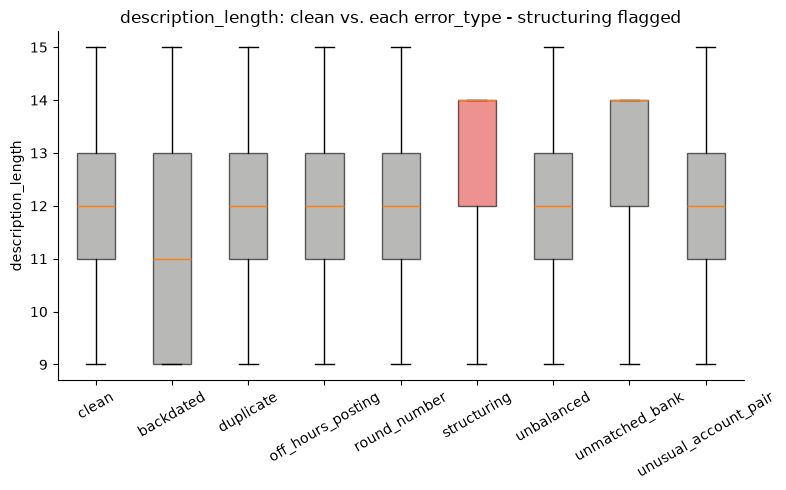

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
group_order = ["clean"] + sorted(desc_exploded["error_type"].unique())
data_by_group = [desc_df.loc[~desc_df["is_error"], "description_length"]] + [
    desc_exploded.loc[desc_exploded["error_type"] == et, "description_length"] for et in group_order[1:]
]
box_colors = ["#8a8a86" if g != "structuring" else "#e34948" for g in group_order]  # neutral gray, structuring in status-red

bp = ax.boxplot(data_by_group, tick_labels=group_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("description_length")
ax.set_title("description_length: clean vs. each error_type - structuring flagged")
ax.tick_params(axis="x", rotation=30)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [28]:
%%sql structuring_sample_rs <<
SELECT h.header_id, h.entry_description, LENGTH(h.entry_description) AS description_length
FROM journal_header h
JOIN ground_truth g ON g.header_id = h.header_id AND g.error_type = 'structuring'
ORDER BY h.header_id
LIMIT 8;

In [29]:
structuring_sample_rs.DataFrame()

,header_id,entry_description,description_length
0,113287,Vendor Payment,14
1,113288,Vendor Payment,14
2,113289,Cash Receipt,12
3,113290,Cash Receipt,12
4,113291,Cash Receipt,12
5,113292,Cash Receipt,12
6,113293,Cash Receipt,12
7,113294,Cash Receipt,12


**Verdict: confirmed, then fixed, then verified.**

**What was found (original run):** `structuring` headers averaged a
`description_length` of 24.9 (std 1.33, range 21-26); every other group -
clean baseline included - sat in 11-14, with clean's own max topping out at
21. That's not overlapping distributions with a shifted mean, it was close
to full separation on a single feature. The sample text confirmed the
mechanism directly: the generator appended literal `" (split 1/3)"`,
`" (split 2/3)"`, etc. to the original description for every
structuring-split header (`data/generate_journal_entries.py`, the
structuring block), adding a near-constant ~12-14 characters no real-world
structuring pattern would announce itself with. That explained two things
at once - Section 9's #3 SHAP rank for `description_length`, and Section
8's suspiciously perfect 1.000 recall on `structuring` for all three
models despite `structuring` being labelled `hard` detectability
(CLAUDE.md's Hard rules: "seeded errors must vary in detectability... if
everything is easy to catch, the recall number is meaningless").

**What was changed:** the suffix append was removed from the structuring
block in `data/generate_journal_entries.py` - `entry_description` is now
left exactly as the original entry's. The split relationship (which piece,
of how many, from what original total) is still fully recorded, just in
`ground_truth.notes` instead of a field the feature table reads. The data
was regenerated end-to-end (`sql/01_schema.sql` reset, generator re-run
with the same `RNG_SEED = 42`, `sql/00_sanity_checks.sql` re-verified
row counts/balance/error mix/lag/amount distributions all unchanged),
`journal_entry_features` rebuilt, and notebooks 01-04 re-executed against
the regenerated DB - the numbers in this notebook, including the cells
above in this section, are all post-fix.

**What the re-run confirms:** `structuring`'s `description_length` now
averages 12.91 (range 9-14) - indistinguishable from the 12.26 clean
baseline and every other error type, exactly where it should sit for a
field the seeding mechanism never touches. `description_length`'s SHAP
rank dropped from #3 (mean|SHAP| 0.233) to #12 (0.134) in Section 9 - still
a real, moderate feature, no longer an inflated one. `structuring`'s recall
(Section 8) dropped from a suspicious 1.000/1.000/1.000 to
0.864/0.682/0.868 (LR/RF/XGB) - still fairly high, because the *intended*
signal (amounts kept just under the $10k threshold, `total_amount` and
`is_round_100`/`account_pair_frequency` picking up the same-account/
same-employee repost pattern) is real and learnable, but no longer a
trivial 100% giveaway from a generation-mechanism tell. That's what
`structuring`'s `hard` detectability label was supposed to mean, and now
the recall number actually reflects it.

**Why this matters beyond `structuring` itself:** it's a concrete
demonstration of exactly the risk CLAUDE.md's "Seeded errors must vary in
detectability" rule is guarding against - a synthetic-data generator can
accidentally hand a model a free tell that has nothing to do with the
phenomenon it's supposed to be teaching the model to recognize, and a high
recall number on its own doesn't distinguish "the model learned the real
pattern" from "the model found the seam in how the data was made." Worth
keeping in mind for `backdated`, `duplicate`, and the rest going into
Phase 5 - this was the one field-level leak this audit (Section 11's
opening cells) found, not a guarantee there are none left.